### Import the modules

In [51]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from pathlib import Path
import sys 
import os 
import math

In [52]:
current_dir = Path.cwd()
project_root = current_dir.parent.parent.parent
scripts_dir = (
    project_root
    / 'SystemicRiskCopulaProject'
    / 'Scripts'
)
if str(scripts_dir) not in sys.path:
    scripts_dir = (
        Path.home()
        / 'Projects'
        / 'Ian'
        / 'CommodityProject'
        / 'SystemicRiskCopulaProject'
        / 'Scripts'
    )


In [53]:
%cd $project_root 

c:\


In [54]:
import CommodityProject.SystemicRiskCopulaProject.Scripts.BasicOperations as basic
import importlib

importlib.reload(basic)

<module 'CommodityProject.SystemicRiskCopulaProject.Scripts.BasicOperations' from 'c:\\Users\\BudgetGamer\\Projects\\Ian\\CommodityProject\\SystemicRiskCopulaProject\\Scripts\\BasicOperations.py'>

### Data gathering

In [55]:
#Henry Hub Natural Gas
df_ng = yf.download("NG=F", start="2016-01-01", end="2026-08-31", interval="1d")
#Copper
df_cu = yf.download("HG=F", start="2016-01-01", end="2026-08-31", interval="1d")
#Brent
df_bz = yf.download("BZ=F", start="2016-01-01", end="2026-08-31", interval="1d")
#Corn
df_zc = yf.download("ZC=F", start="2016-01-01", end="2026-08-31", interval="1d")
#Crude Oil WTI
df_cl = yf.download("CL=F", start="2016-01-01", end="2026-08-31", interval="1d")
#Cattle-Live
df_le = yf.download("LE=F", start="2016-01-01", end="2026-08-31", interval="1d")
#Cocoa
df_cc = yf.download("CC=F", start="2016-01-01", end="2026-08-31", interval="1d")

[*********************100%***********************]  1 of 1 completed


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


### Data preprocessing

In [56]:
# Reset index and rename columns 
try:
    for df in [df_ng, df_cu, df_bz, df_zc, df_cl, df_le, df_cc]:
        df.dropna(inplace=True)
        df.reset_index(inplace=True, names = 'Date')
        df.columns = ['Date','Close', 'High', 'Low', 'Open', 'Volume']
except Exception as e:
    print(f"An error occurred: {e}")
    pass

In [57]:
print(f'Size before algnment: {df_cl.shape, df_cu.shape, df_bz.shape, df_zc.shape, df_le.shape, df_cc.shape , df_ng.shape}')

df_ng, df_cu, df_bz, df_zc, df_cl, df_le, df_cc = basic.aligning_dataframes(df_ng, df_cu, df_bz, df_zc, df_cl, df_le, df_cc)

print(f'Size after algnment: {df_cl.shape, df_cu.shape, df_bz.shape, df_zc.shape, df_le.shape, df_cc.shape , df_ng.shape}')


Size before algnment: ((2679, 6), (2679, 6), (2680, 6), (2676, 6), (2678, 6), (2679, 6), (2680, 6))
Size after algnment: ((2679, 6), (2679, 6), (2680, 6), (2676, 6), (2678, 6), (2679, 6), (2680, 6))


In [58]:
dfs = {
    "NG": df_ng,
    "Copper": df_cu,
    "Brent": df_bz,
    "Corn": df_zc,
    "WTI": df_cl,
    "Cattle": df_le,
    "Cocoa": df_cc
}

In [59]:
allDates = pd.concat(df['Date'] for df in dfs.values()).drop_duplicates().sort_values()
for name, _df in dfs.items():
    missingDates = allDates[~allDates.isin(_df['Date'])]
    print(f'{name} has {missingDates}')


NG has Series([], Name: Date, dtype: datetime64[s])
Copper has 519   2018-01-29
Name: Date, dtype: datetime64[s]
Brent has Series([], Name: Date, dtype: datetime64[s])
Corn has 742    2018-12-17
743    2018-12-18
1985   2023-11-23
2389   2025-07-04
Name: Date, dtype: datetime64[s]
WTI has 1985   2023-11-23
Name: Date, dtype: datetime64[s]
Cattle has 1985   2023-11-23
2389   2025-07-04
Name: Date, dtype: datetime64[s]
Cocoa has 1985   2023-11-23
Name: Date, dtype: datetime64[s]


**Imputation and fill missing logic**:

It's best to use fill forward for commodity data mainly because
1. Look ahead bias : Interpolation uses future price data to estimate past missing prices.In trading models, this creates leakage from the future that distorts performance results
2. Real market value on weekends and holidays are represented by previous day price rather than avg
3. To preserve "Zero return days" on holidays

In [60]:
dfs = {
    name: basic.fillMissingDates(frame)
    for name, frame in dfs.items()
}

for name, _df in dfs.items():
    missingDates = allDates[~allDates.isin(_df['Date'])]
    print(f'{name} has {missingDates}')


NG has Series([], Name: Date, dtype: datetime64[s])
Copper has Series([], Name: Date, dtype: datetime64[s])
Brent has Series([], Name: Date, dtype: datetime64[s])
Corn has Series([], Name: Date, dtype: datetime64[s])
WTI has Series([], Name: Date, dtype: datetime64[s])
Cattle has Series([], Name: Date, dtype: datetime64[s])
Cocoa has Series([], Name: Date, dtype: datetime64[s])


**Remove negative prices because of log return issue**

Why?
> It would cause errors in log-returns as neg logs are not defined

How to fix this issue?
> Add a noise to the all series, so that all series are shifted by the same degree. Normally, s is global min(price) + small value



In [61]:
'''
for nm, df in zip(['df_ng', 'df_cu', 'df_bz', 'df_zc', 'df_cl', 'df_le', 'df_cc'], [df_ng, df_cu, df_bz, df_zc, df_cl, df_le, df_cc]):
    _df = df[df['Close'] < 0].copy().dropna(how = 'all')
    if len(_df) > 0:
        print(len(_df))    
        '''

"\nfor nm, df in zip(['df_ng', 'df_cu', 'df_bz', 'df_zc', 'df_cl', 'df_le', 'df_cc'], [df_ng, df_cu, df_bz, df_zc, df_cl, df_le, df_cc]):\n    _df = df[df['Close'] < 0].copy().dropna(how = 'all')\n    if len(_df) > 0:\n        print(len(_df))    \n        "

>> In here, the number of occurance of negative value is just a few so its unnecessary to do the global shift and verify it. What I'll do in here is just do an ffill with a mask.

In [62]:
for name, df in dfs.items():
    if len(df[df['Close'] < 0].copy().dropna(how = 'all')) > 0:
        df['Close'] = df['Close'].mask(df['Close']<=0).ffill()
        print(f"Negative value replaced by forward fill in {name} series")


Negative value replaced by forward fill in WTI series


### Calculate returns- log return, percentage change and relative change

In [63]:
try:
    for name, df in dfs.items():
        df['Percentage_Returns'] = df['Close'].pct_change()
        df['Relative_change'] =df['Close'] - df['Close'].shift(-1)
        df['Log_Returns'] = np.log(df['Close'] / df['Close'].shift(1))
        df.drop(['High', 'Low', 'Open'], axis=1, inplace=True)
        #df.drop(df.index[0], inplace=True)
        print(f"Done w {name}")
except Exception as e:
    print(f"Exception {e} occurred while parsing {name}")
    pass

Done w NG
Done w Copper
Done w Brent
Done w Corn
Done w WTI
Done w Cattle
Done w Cocoa


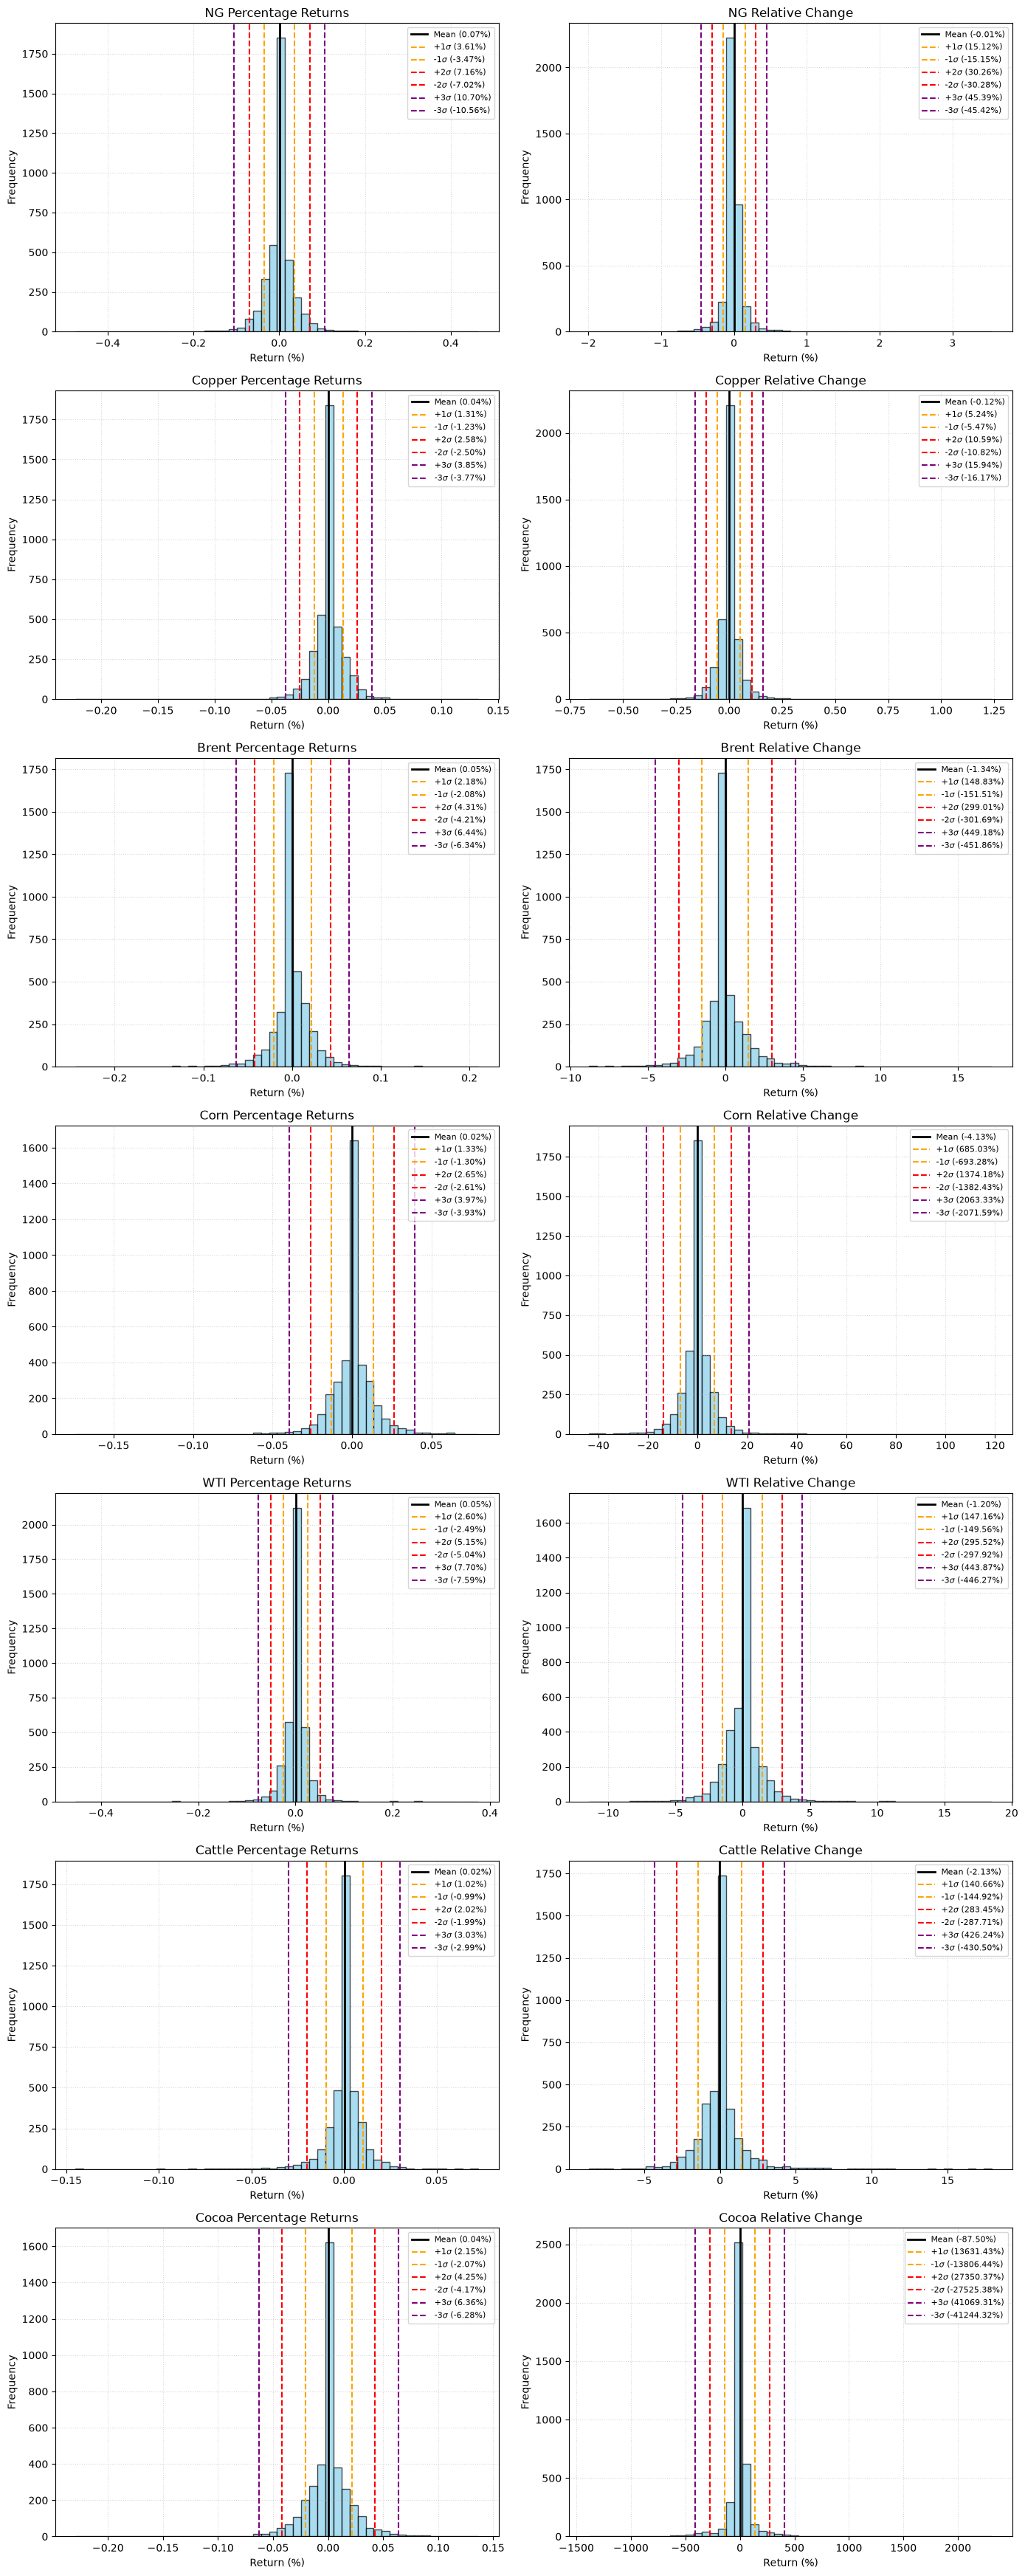

In [64]:
ncols = 2
nrows = len(dfs)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(14, 5 * nrows),
    squeeze=False
)

for row, (name, df) in enumerate(dfs.items()):
    basic.plot_histogram(
        df['Percentage_Returns'],
        ax=axes[row, 0],
        title=f"{name} Percentage Returns"
    )

    basic.plot_histogram(
        df['Relative_change'],
        ax=axes[row, 1],
        title=f"{name} Relative Change"
    )

plt.tight_layout()
plt.show()

In [46]:
importlib.reload(basic)

<module 'CommodityProject.SystemicRiskCopulaProject.Scripts.BasicOperations' from 'c:\\Users\\BudgetGamer\\Projects\\Ian\\CommodityProject\\SystemicRiskCopulaProject\\Scripts\\BasicOperations.py'>

In [67]:
ncols = 2
nrows = math.ceil(len(dfs) / ncols)

fig = make_subplots(
    rows=nrows,
    cols=ncols,
    subplot_titles=list(dfs.keys()),
    horizontal_spacing=0.12,
    vertical_spacing=0.18,
)

for idx, (name, df) in enumerate(dfs.items()):
    row = idx // ncols + 1
    col = idx % ncols + 1

    basic.plot_histogram_interactive(
        fig,
        df["Percentage_Returns"],
        row,
        col,
        title=name,
        bins=50,
    )

fig.update_layout(
    title="Commodity Percentage Return Histograms",
    template="plotly_white",
    height=350 * nrows,
    width=1400,
    showlegend=False,
)

fig.update_xaxes(
    title_text="Return",
    tickformat=".2%",
)

fig.update_yaxes(title_text="Frequency")

fig.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed